In [14]:
# Import packages
from pprint import pprint
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import sys
from matplotlib import rcParams
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['font.weight'] = 'normal'
rcParams['axes.formatter.useoffset'] = False

In [15]:
# Import etc
import wcc_etc

In [16]:
scene = wcc_etc.get_scene(name='G5V', 
                          mag=25.4, 
                          host=None, 
                          background="zodi",
                          bandpass='johnson_r',
                          background_prop={"bandpass": 'johnson_r', "mag": 22.5})

# Define the sensor and filter combination
sensor_and_filter = 'sony:r'
simu = wcc_etc.Simulation.from_sensor_and_scene(sensor_and_filter, scene)

snr_val = simu.get_snr(time = 60)
snr_val

<Quantity 5.16240375>

In [17]:
# Update different values
simu.update(jitter_sigma=10)

# change different properties (see self.mutable_parameters)
_ = simu.update(source__mag=22, dark_current=simu.meta['sensor']['dark_current']*10)


# and re-compute the signal to noise ratio
snr = simu.get_snr(time=60) # could be an array. It broadcasts
snr

<Quantity 50.47932954>

In [18]:
# Verify that settings are updated. simu.meta has all of the parameters of interest
pprint(simu.meta)

{'r_aper_mas': 70,
 'scene': {'background': {'bandpass': 'johnson_r',
                          'mag': 22.5,
                          'magsys': 'ABmag',
                          'spectrum': 'zodi',
                          'surface_brightness': True},
           'source': {'bandpass': 'johnson_r',
                      'mag': 22,
                      'magsys': 'ABmag',
                      'spectrum': 'G5V',
                      'surface_brightness': False}},
 'sensor': {'area': <Quantity 864. mm2>,
            'dark_current': 0.030703367499985944,
            'gain': 0.261200000004368,
            'gain_setting': 100,
            'path_dark_current': 'sensors/ZWO_ASI6200MM/ZWO_ASI6200MM_Pro_Dark_Current_vs_Sensor_Temperature.csv',
            'path_gain_curve': 'sensors/ZWO_ASI6200MM/ZWO_ASI6200MM_Pro_Gain_vs_Gain_Setting.csv',
            'path_qe': '',
            'path_read_noise': 'sensors/ZWO_ASI6200MM/ZWO_ASI6200MM_Pro_Read_Noise_vs_Gain_Setting.csv',
            'path_tot

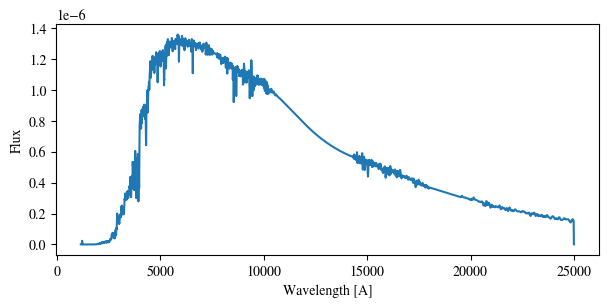

In [19]:
# plot
simu.scene.source.show();

In [20]:
# get arrays directly
w, f = simu.scene.source.get_spectrum()._get_arrays(wavelengths=None)
w, f

(<Quantity [ 1150.,  1155.,  1160., ..., 24990., 24995., 25000.] Angstrom>,
 <Quantity [6.47438353e-10, 6.44550040e-10, 3.57906382e-10, ...,
            1.91383695e-08, 0.00000000e+00, 0.00000000e+00] PHOTLAM>)

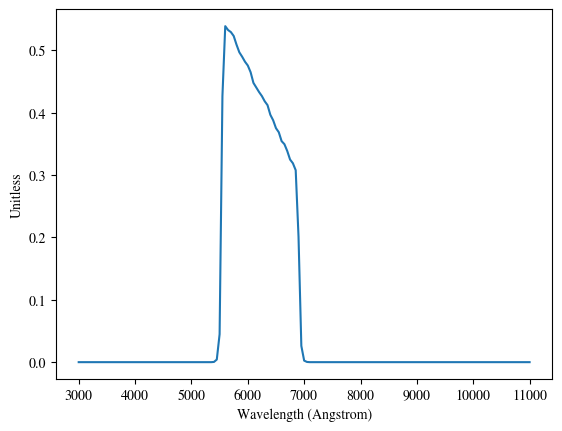

In [21]:
# plot bandpass
simu.sensor.bandpass.plot()